# Forecasting Financial Inclusion in Ethiopia
## Interim Submission - Task 1: Data Exploration and Enrichment; Task 2: Exploratory Data Analysis

This executed notebook examines the unified financial inclusion schema, verifies the documented enrichment, and analyzes Ethiopia's **Access** and **Usage** outcomes. It also evaluates infrastructure, event timing, impact-link assumptions, data quality, and analytical limitations.

## Objectives

1. Load the starter, enriched, and reference-code datasets.
2. Demonstrate how `observation`, `event`, `impact_link`, and `target` rows share one schema.
3. Verify that events stay pillar-neutral and impact links connect events to indicators through `parent_id`.
4. Summarize coverage by record type, pillar, source type, confidence, indicator, and year.
5. Analyze account ownership, mobile money, digital payments, infrastructure, gender, and registered-versus-active gaps.
6. Overlay key events on indicator trends and document at least five evidence-backed insights.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_reference_codes, load_unified_data, split_records, validate_schema
from src.eda import (
    account_ownership_series,
    growth_rates,
    impact_matrix,
    indicator_coverage,
    joined_impact_links,
    normalized_gap,
    observation_series,
    pairwise_indicator_correlations,
    record_summary,
    temporal_coverage_matrix,
)

RAW_PATH = ROOT / "data/raw/ethiopia_fi_unified_data.csv"
ENRICHED_PATH = ROOT / "data/processed/ethiopia_fi_enriched.csv"
REF_PATH = ROOT / "data/raw/reference_codes.csv"
FIG_DIR = ROOT / "reports/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

raw = load_unified_data(RAW_PATH)
df = load_unified_data(ENRICHED_PATH)
refs = load_reference_codes(REF_PATH)
records = split_records(df)

print(f"Raw unified dataset: {raw.shape[0]} records x {raw.shape[1]} columns")
print(f"Enriched dataset:    {df.shape[0]} records x {df.shape[1]} columns")
print(f"Reference codes:     {refs.shape[0]} rows x {refs.shape[1]} columns")
print(f"Added records:       {len(df) - len(raw)}")

Raw unified dataset: 57 records x 35 columns
Enriched dataset:    65 records x 35 columns
Reference codes:     71 rows x 4 columns
Added records:       8


## 1. Schema Understanding

The schema avoids assigning interpretations directly to events:

- **observation:** an actual measured value; `pillar` and `indicator_code` are required.
- **target:** an official goal; `pillar` identifies the outcome dimension.
- **event:** a neutral policy, product, market, infrastructure, or economic occurrence; `category` is filled and `pillar` is intentionally blank.
- **impact_link:** an analytical relationship from an event to a specific indicator; `parent_id` points to the event's `record_id`, while `pillar`, `related_indicator`, direction, magnitude, lag, and evidence describe the hypothesized effect.

This design allows one event to affect several pillars without forcing a single biased event classification.

In [2]:
record_type_example = df.groupby("record_type", dropna=False).head(2)[
    ["record_id", "parent_id", "record_type", "category", "pillar", "indicator", "indicator_code", "related_indicator"]
].sort_values(["record_type", "record_id"])
display(record_type_example)

joined_example = joined_impact_links(df)[
    ["record_id", "parent_id", "event_name", "event_category", "pillar", "related_indicator", "impact_direction", "lag_months"]
].head(10)
display(Markdown("**Example: impact links joined to neutral events through `parent_id`:**"))
display(joined_example)

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,related_indicator
33,EVT_0001,<NA>,event,product_launch,<NA>,Telebirr Launch,EVT_TELEBIRR,<NA>
34,EVT_0002,<NA>,event,market_entry,<NA>,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,<NA>
43,IMP_0001,EVT_0001,impact_link,<NA>,ACCESS,Telebirr effect on Account Ownership,<NA>,ACC_OWNERSHIP
44,IMP_0002,EVT_0001,impact_link,<NA>,USAGE,Telebirr effect on Telebirr Users,<NA>,USG_TELEBIRR_USERS
0,REC_0001,<NA>,observation,<NA>,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,<NA>
1,REC_0002,<NA>,observation,<NA>,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,<NA>
30,REC_0031,<NA>,target,<NA>,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,<NA>
31,REC_0032,<NA>,target,<NA>,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,<NA>


**Example: impact links joined to neutral events through `parent_id`:**

,record_id,parent_id,event_name,event_category,pillar,related_indicator,impact_direction,lag_months
0,IMP_0001,EVT_0001,Telebirr Launch,product_launch,ACCESS,ACC_OWNERSHIP,increase,12.0
1,IMP_0002,EVT_0001,Telebirr Launch,product_launch,USAGE,USG_TELEBIRR_USERS,increase,3.0
2,IMP_0003,EVT_0001,Telebirr Launch,product_launch,USAGE,USG_P2P_COUNT,increase,6.0
3,IMP_0004,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,ACCESS,ACC_4G_COV,increase,12.0
4,IMP_0005,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,AFFORDABILITY,AFF_DATA_INCOME,decrease,12.0
5,IMP_0006,EVT_0003,M-Pesa Ethiopia Launch,product_launch,USAGE,USG_MPESA_USERS,increase,3.0
6,IMP_0007,EVT_0003,M-Pesa Ethiopia Launch,product_launch,ACCESS,ACC_MM_ACCOUNT,increase,6.0
7,IMP_0008,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,ACCESS,ACC_OWNERSHIP,increase,24.0
8,IMP_0009,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,GENDER,GEN_GAP_ACC,decrease,24.0
9,IMP_0010,EVT_0005,Foreign Exchange Liberalization,policy,AFFORDABILITY,AFF_DATA_INCOME,increase,3.0


### Schema Validation

The checks below test unique IDs, valid record types, event pillar neutrality, required pillars, event categories, observation indicator codes, and valid event parents for every impact link.

In [3]:
issues = validate_schema(df)
if issues.empty:
    print("PASS: No schema validation issues found.")
else:
    display(issues)

PASS: No schema validation issues found.


## 2. Enrichment Verification

The enrichment adds the missing 2011 access baseline, core 2024 Findex usage measures, supply-side registration and activity indicators, the 2025 NDPS Phase Two event, and two transparent event-impact hypotheses. Full provenance is documented in `data_enrichment_log.md`.

In [4]:
added = df.loc[~df["record_id"].isin(raw["record_id"])].copy()
display(added[[
    "record_id", "parent_id", "record_type", "category", "pillar", "indicator",
    "value_numeric", "observation_date", "source_name", "confidence", "related_indicator"
]])

,record_id,parent_id,record_type,category,pillar,indicator,value_numeric,observation_date,source_name,confidence,related_indicator
57,REC_0034,<NA>,observation,<NA>,ACCESS,Account Ownership Rate,14.0,2011-12-31,Global Findex 2011,high,<NA>
58,REC_0035,<NA>,observation,<NA>,USAGE,Made or Received a Digital Payment,35.0,2024-11-30,Global Findex 2024,medium,<NA>
59,REC_0036,<NA>,observation,<NA>,USAGE,Used Account to Receive Wages,15.0,2024-11-30,Global Findex 2024,medium,<NA>
60,REC_0037,<NA>,observation,<NA>,ACCESS,Registered Mobile Money Accounts,128500000.0,2024-12-31,National Bank of Ethiopia,high,<NA>
61,REC_0038,<NA>,observation,<NA>,USAGE,Active Mobile Money Account Share,15.0,2025-12-09,NBE Draft National Digital Payments Strategy 2...,medium,<NA>
62,EVT_0011,<NA>,event,policy,<NA>,National Digital Payments Strategy Phase Two L...,NaN,2025-03-28,National Bank of Ethiopia,high,<NA>
63,IMP_0015,EVT_0011,impact_link,<NA>,USAGE,NDPS Phase Two effect on Digital Payment Adoption,10.0,2025-03-28,National Bank of Ethiopia,medium,USG_DIGITAL_PAYMENT
64,IMP_0016,EVT_0011,impact_link,<NA>,ACCESS,NDPS Phase Two effect on Account Ownership,5.0,2025-03-28,National Bank of Ethiopia,medium,ACC_OWNERSHIP


## 3. Dataset Overview

In [5]:
summaries = record_summary(df)
summary_long = pd.concat(
    [table.assign(dimension=name) for name, table in summaries.items()],
    ignore_index=True,
)
summary_long.to_csv(ROOT / "data/processed/record_summary.csv", index=False)

for name, table in summaries.items():
    display(Markdown(f"**Records by {name}:**"))
    display(table)

**Records by record_type:**

,record_type,count
0,observation,35
1,impact_link,16
2,event,11
3,target,3


**Records by pillar:**

,pillar,count
0,ACCESS,23
1,USAGE,21
2,(blank / event-neutral),11
3,GENDER,6
4,AFFORDABILITY,4


**Records by source_type:**

,source_type,count
0,operator,15
1,(missing),14
2,survey,13
3,regulator,8
4,policy,7
5,research,4
6,calculated,2
7,news,2


**Records by confidence:**

,confidence,count
0,high,47
1,medium,18


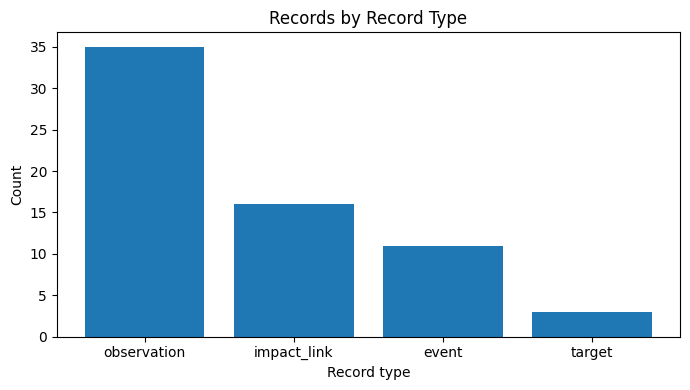

In [6]:
record_counts = summaries["record_type"]
plt.figure(figsize=(7, 4))
plt.bar(record_counts["record_type"], record_counts["count"])
plt.title("Records by Record Type")
plt.xlabel("Record type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_record_type_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

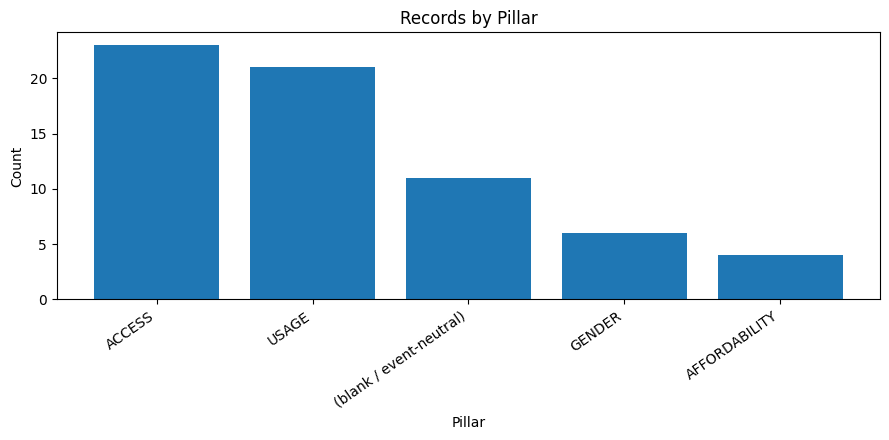

In [7]:
pillar_counts = summaries["pillar"]
plt.figure(figsize=(9, 4.5))
plt.bar(pillar_counts["pillar"], pillar_counts["count"])
plt.title("Records by Pillar")
plt.xlabel("Pillar")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_pillar_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

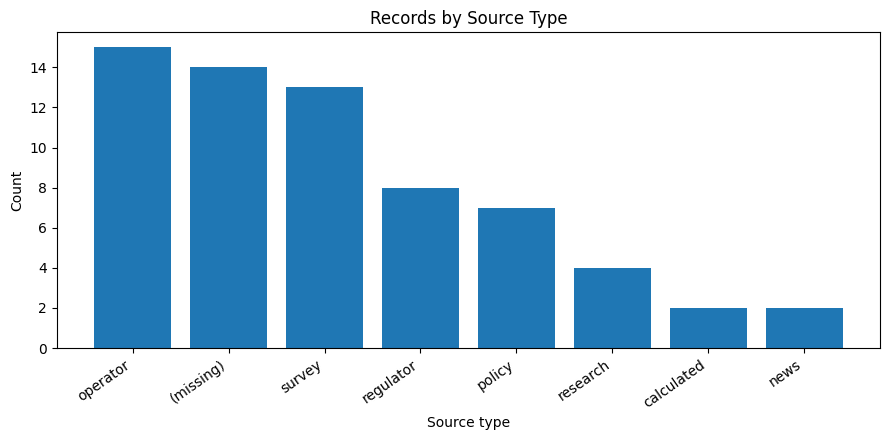

In [8]:
source_counts = summaries["source_type"]
plt.figure(figsize=(9, 4.5))
plt.bar(source_counts["source_type"], source_counts["count"])
plt.title("Records by Source Type")
plt.xlabel("Source type")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_source_type_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

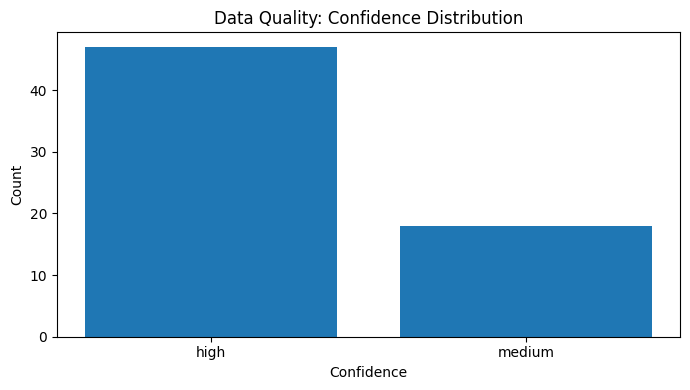

In [9]:
confidence_counts = summaries["confidence"]
plt.figure(figsize=(7, 4))
plt.bar(confidence_counts["confidence"], confidence_counts["count"])
plt.title("Data Quality: Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_confidence_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

### Temporal Range and Indicator Coverage

In [10]:
observations = records["observation"].copy()
print("Observation date range:", observations["observation_date"].min().date(), "to", observations["observation_date"].max().date())
print("Unique observation indicators:", observations["indicator_code"].nunique())

coverage = indicator_coverage(df)
coverage.to_csv(ROOT / "data/processed/indicator_coverage.csv", index=False)
display(coverage)

sparse_share = (coverage["unique_years"] <= 1).mean() * 100
print(f"Indicators with only one observed year: {sparse_share:.1f}%")

Observation date range: 2011-12-31 to 2025-12-31
Unique observation indicators: 23


,indicator_code,indicator,observations,first_year,last_year,unique_years,confidence_modes
3,ACC_MM_REGISTERED,Registered Mobile Money Accounts,1,2024,2024,1,high
4,ACC_MOBILE_PEN,Mobile Subscription Penetration,1,2025,2025,1,high
6,AFF_DATA_INCOME,Data Affordability Index,1,2024,2024,1,medium
8,GEN_GAP_MOBILE,Mobile Phone Gender Gap,1,2024,2024,1,high
9,GEN_MM_SHARE,Female Mobile Money Account Share,1,2024,2024,1,high
10,USG_ACTIVE_RATE,Mobile Money Activity Rate,1,2024,2024,1,high
11,USG_ATM_COUNT,ATM Transaction Count,1,2025,2025,1,high
12,USG_ATM_VALUE,ATM Transaction Value,1,2025,2025,1,high
13,USG_CROSSOVER,P2P/ATM Crossover Ratio,1,2025,2025,1,high
14,USG_DIGITAL_PAYMENT,Made or Received a Digital Payment,1,2024,2024,1,medium


Indicators with only one observed year: 73.9%


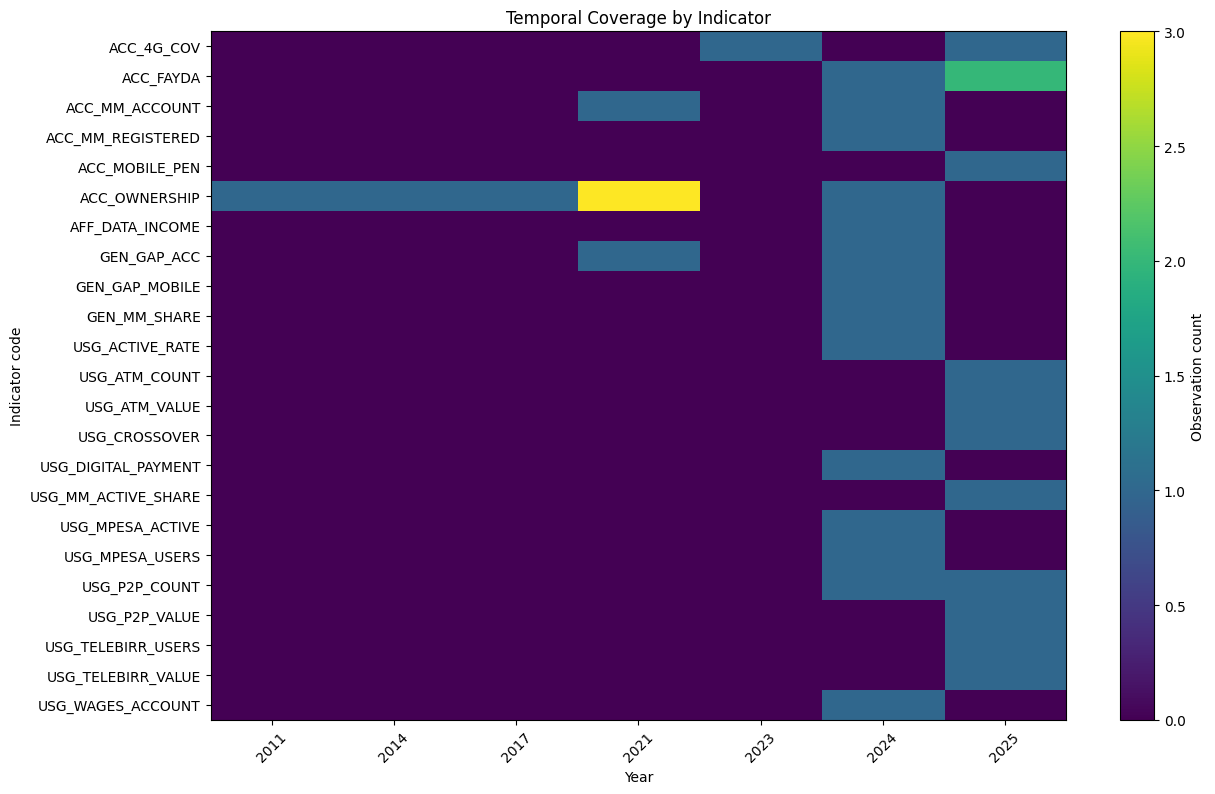

In [11]:
coverage_matrix = temporal_coverage_matrix(df)
plt.figure(figsize=(13, max(6, 0.35 * len(coverage_matrix))))
plt.imshow(coverage_matrix.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="Observation count")
plt.xticks(range(len(coverage_matrix.columns)), coverage_matrix.columns.astype(int), rotation=45)
plt.yticks(range(len(coverage_matrix.index)), coverage_matrix.index)
plt.title("Temporal Coverage by Indicator")
plt.xlabel("Year")
plt.ylabel("Indicator code")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_temporal_coverage.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Access Analysis

### Account Ownership Trajectory, 2011-2024

,year,value_numeric,confidence,source_name
57,2011,14.0,high,Global Findex 2011
0,2014,22.0,high,Global Findex 2014
1,2017,35.0,high,Global Findex 2017
2,2021,46.0,high,Global Findex 2021
5,2024,49.0,high,Global Findex 2024


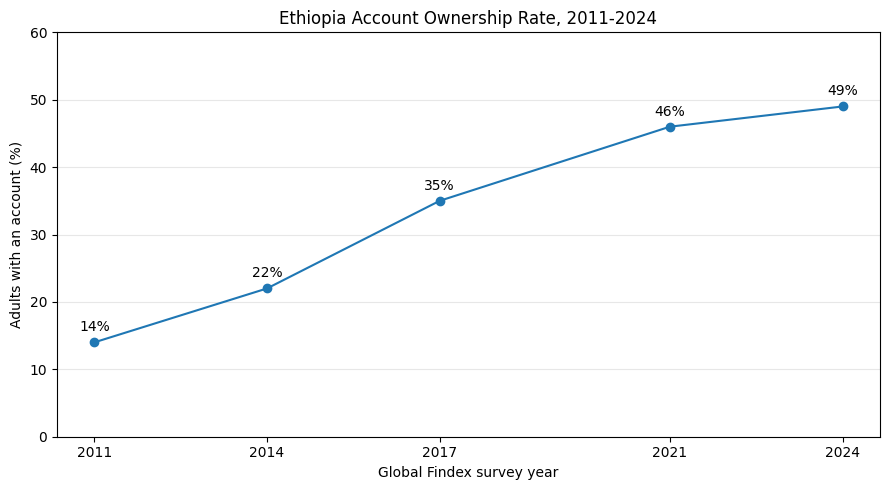

In [12]:
account = account_ownership_series(df)
display(account[["year", "value_numeric", "confidence", "source_name"]])

plt.figure(figsize=(9, 5))
plt.plot(account["year"], account["value_numeric"], marker="o")
for _, row in account.iterrows():
    plt.annotate(f"{row['value_numeric']:.0f}%", (row["year"], row["value_numeric"]), xytext=(0, 8), textcoords="offset points", ha="center")
plt.title("Ethiopia Account Ownership Rate, 2011-2024")
plt.xlabel("Global Findex survey year")
plt.ylabel("Adults with an account (%)")
plt.xticks(account["year"].astype(int))
plt.ylim(0, 60)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_account_ownership_trajectory.png", dpi=160, bbox_inches="tight")
plt.show()

,period,change_pp,annualized_pp
1,2011-2014,8.0,2.67
2,2014-2017,13.0,4.33
3,2017-2021,11.0,2.75
4,2021-2024,3.0,1.00


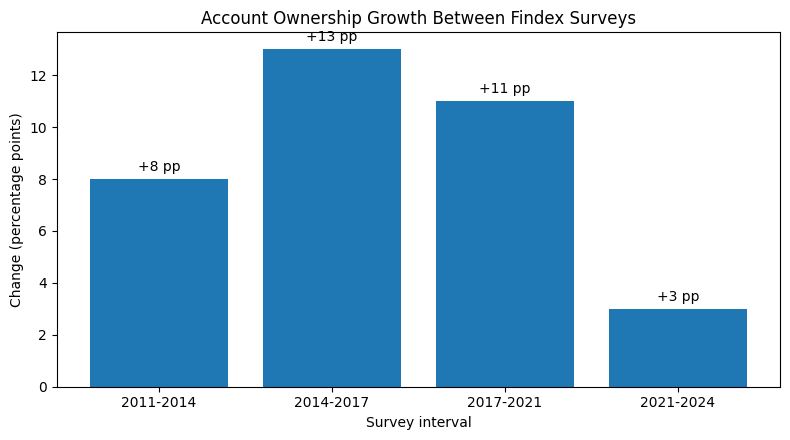

In [13]:
growth = growth_rates(account)
display(growth[["period", "change_pp", "annualized_pp"]].round(2))

plt.figure(figsize=(8, 4.5))
plt.bar(growth["period"], growth["change_pp"])
for i, value in enumerate(growth["change_pp"]):
    plt.text(i, value + 0.3, f"+{value:.0f} pp", ha="center")
plt.title("Account Ownership Growth Between Findex Surveys")
plt.xlabel("Survey interval")
plt.ylabel("Change (percentage points)")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_account_growth_rates.png", dpi=160, bbox_inches="tight")
plt.show()

### Investigating the 2021-2024 Slowdown

Account ownership increased from **46% to 49%**, only **+3 percentage points** or about **+1 pp per year**. This is a marked deceleration relative to earlier survey intervals, even while operator registrations and digital transaction volumes expanded rapidly.

The most plausible interpretation is not that digital finance stopped growing, but that supply-side account counts and demand-side unique-adult inclusion measure different things. One adult may hold multiple bank and mobile-money accounts; registered accounts may be inactive; and new mobile-money users may already have bank accounts. Persistent gender, rural, identity, merchant-acceptance, trust, and digital-literacy barriers can also slow conversion into broad, active inclusion.

### Gender Gap

,gender,value_numeric
4,female,36.0
3,male,56.0


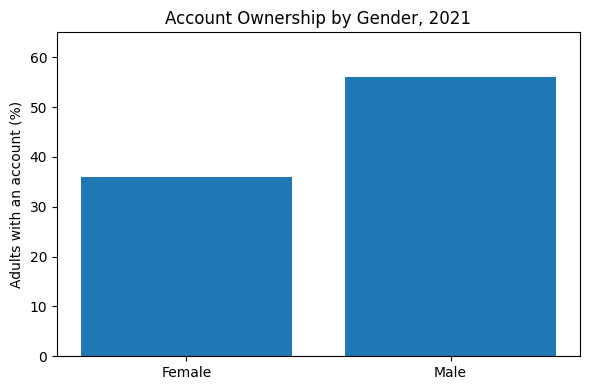

,year,value_numeric,confidence,source_name
26,2021,20.0,high,Global Findex 2021
27,2024,18.0,medium,Global Findex 2024


In [14]:
gender_2021 = df.loc[
    df["record_type"].eq("observation")
    & df["indicator_code"].eq("ACC_OWNERSHIP")
    & df["observation_date"].dt.year.eq(2021)
    & df["gender"].isin(["male", "female"]),
    ["gender", "value_numeric"],
].sort_values("gender")
display(gender_2021)

plt.figure(figsize=(6, 4))
plt.bar(gender_2021["gender"].str.title(), gender_2021["value_numeric"])
plt.title("Account Ownership by Gender, 2021")
plt.ylabel("Adults with an account (%)")
plt.ylim(0, 65)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_gender_ownership_2021.png", dpi=160, bbox_inches="tight")
plt.show()

estimated_gap = observation_series(df, "GEN_GAP_ACC")
display(estimated_gap[["year", "value_numeric", "confidence", "source_name"]])

Urban-versus-rural account ownership is not available in the supplied dataset. This is recorded as a priority data gap rather than imputed.

## 5. Usage and Digital Payments Analysis

### Mobile Money Account Penetration

,year,value_numeric,source_name,confidence
6,2021,4.70,Global Findex 2021,high
7,2024,9.45,Global Findex 2024,high


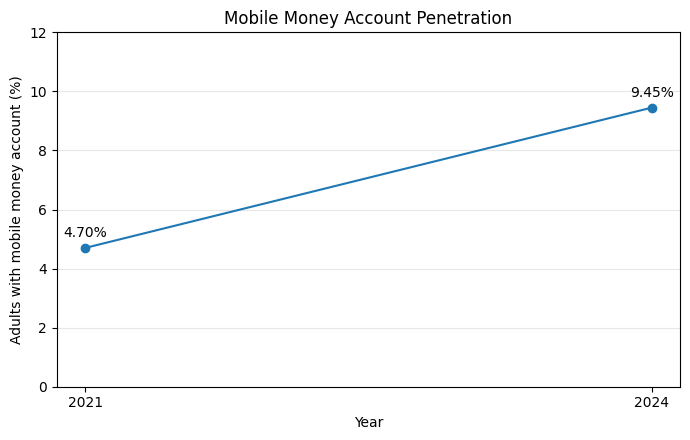

In [15]:
mm_pen = observation_series(df, "ACC_MM_ACCOUNT")
display(mm_pen[["year", "value_numeric", "source_name", "confidence"]])

plt.figure(figsize=(7, 4.5))
plt.plot(mm_pen["year"], mm_pen["value_numeric"], marker="o")
for _, row in mm_pen.iterrows():
    plt.annotate(f"{row['value_numeric']:.2f}%", (row["year"], row["value_numeric"]), xytext=(0, 8), textcoords="offset points", ha="center")
plt.title("Mobile Money Account Penetration")
plt.xlabel("Year")
plt.ylabel("Adults with mobile money account (%)")
plt.xticks(mm_pen["year"].astype(int))
plt.ylim(0, 12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_mobile_money_penetration.png", dpi=160, bbox_inches="tight")
plt.show()

The mobile-money account rate doubled from **4.7% in 2021** to **9.45% in 2024** (+4.75 pp), but it remains far below the overall 49% account-ownership rate. Mobile money is growing quickly, yet it is not the only or dominant measure of national account access.

,indicator,value_numeric
7,Mobile Money Account Rate,9.45
58,Made or Received a Digital Payment,35.00
59,Used Account to Receive Wages,15.00


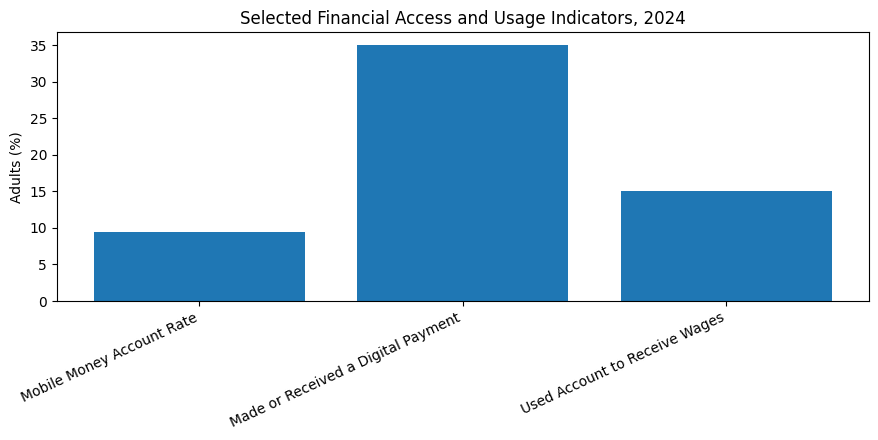

In [16]:
usage_percent_codes = ["ACC_MM_ACCOUNT", "USG_DIGITAL_PAYMENT", "USG_WAGES_ACCOUNT"]
usage_snapshot = df.loc[
    df["record_type"].eq("observation")
    & df["indicator_code"].isin(usage_percent_codes)
    & df["observation_date"].dt.year.eq(2024)
    & df["gender"].fillna("all").eq("all"),
    ["indicator", "value_numeric"],
].drop_duplicates("indicator")
display(usage_snapshot)

plt.figure(figsize=(9, 4.5))
plt.bar(usage_snapshot["indicator"], usage_snapshot["value_numeric"])
plt.title("Selected Financial Access and Usage Indicators, 2024")
plt.ylabel("Adults (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_usage_snapshot_2024.png", dpi=160, bbox_inches="tight")
plt.show()

### Digital Transaction Patterns and P2P/ATM Crossover

,year,value_numeric
14,2024,49700000.0
15,2025,128300000.0


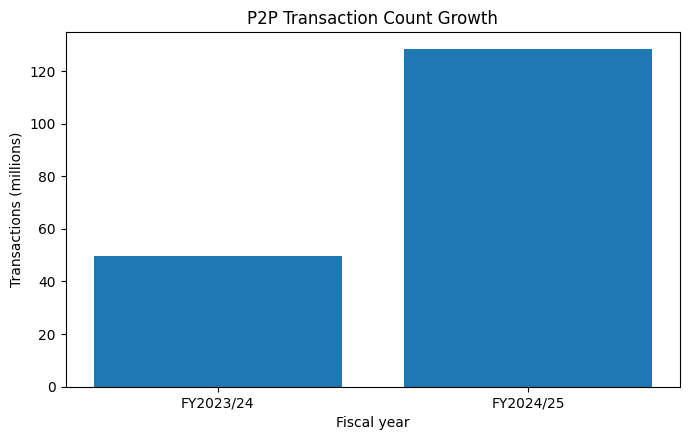

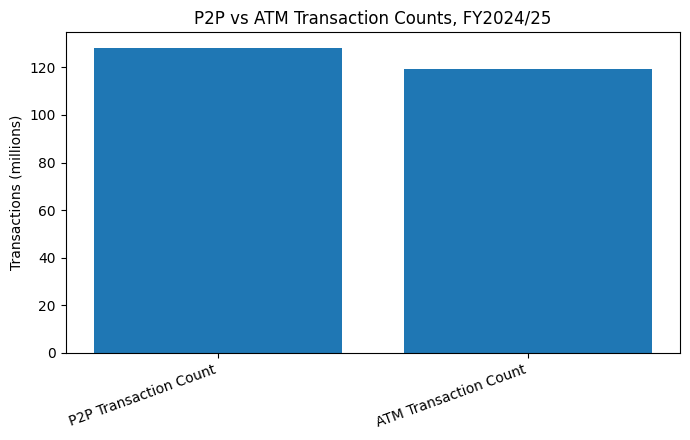

In [17]:
p2p = observation_series(df, "USG_P2P_COUNT")
display(p2p[["observation_date", "fiscal_year" if "fiscal_year" in p2p.columns else "year", "value_numeric"]] if "fiscal_year" in p2p.columns else p2p[["year", "value_numeric"]])

p2p_counts = df.loc[df["indicator_code"].eq("USG_P2P_COUNT"), ["fiscal_year", "value_numeric"]].dropna()
plt.figure(figsize=(7, 4.5))
plt.bar(p2p_counts["fiscal_year"].astype(str), p2p_counts["value_numeric"] / 1_000_000)
plt.title("P2P Transaction Count Growth")
plt.xlabel("Fiscal year")
plt.ylabel("Transactions (millions)")
plt.tight_layout()
plt.savefig(FIG_DIR / "11_p2p_transaction_growth.png", dpi=160, bbox_inches="tight")
plt.show()

latest_channels = df.loc[
    df["record_type"].eq("observation")
    & df["indicator_code"].isin(["USG_P2P_COUNT", "USG_ATM_COUNT"])
    & df["fiscal_year"].astype(str).eq("FY2024/25"),
    ["indicator", "value_numeric"],
]
plt.figure(figsize=(7, 4.5))
plt.bar(latest_channels["indicator"], latest_channels["value_numeric"] / 1_000_000)
plt.title("P2P vs ATM Transaction Counts, FY2024/25")
plt.ylabel("Transactions (millions)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "12_p2p_atm_crossover.png", dpi=160, bbox_inches="tight")
plt.show()

P2P transaction count rose from **49.7 million** to **128.3 million** (+158%) and exceeded the **119.3 million** ATM transactions in FY2024/25. This indicates a rapid channel shift toward digital transfers, even though broad survey-measured account ownership changed slowly.

### Registered-versus-Active Gap

,measure,value_millions
0,M-Pesa registered users,10.8
1,M-Pesa 90-day active users,7.1


M-Pesa activity rate: 65.7%
M-Pesa inactive share: 34.3%
NBE system-wide active account share in the enrichment: 15% (different definition and scope).


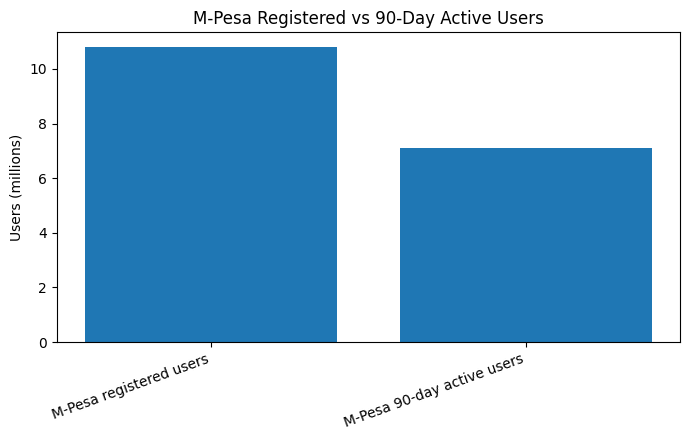

In [18]:
mpesa_registered = df.loc[df["indicator_code"].eq("USG_MPESA_USERS"), "value_numeric"].dropna().iloc[-1]
mpesa_active = df.loc[df["indicator_code"].eq("USG_MPESA_ACTIVE"), "value_numeric"].dropna().iloc[-1]
mpesa_gap = normalized_gap(mpesa_registered, mpesa_active)

gap_table = pd.DataFrame([
    {"measure": "M-Pesa registered users", "value_millions": mpesa_gap["registered"] / 1_000_000},
    {"measure": "M-Pesa 90-day active users", "value_millions": mpesa_gap["active"] / 1_000_000},
])
display(gap_table)
print(f"M-Pesa activity rate: {mpesa_gap['activity_rate']:.1f}%")
print(f"M-Pesa inactive share: {mpesa_gap['inactive_share']:.1f}%")
print("NBE system-wide active account share in the enrichment: 15% (different definition and scope).")

plt.figure(figsize=(7, 4.5))
plt.bar(gap_table["measure"], gap_table["value_millions"])
plt.title("M-Pesa Registered vs 90-Day Active Users")
plt.ylabel("Users (millions)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "13_registered_active_gap.png", dpi=160, bbox_inches="tight")
plt.show()

The provider-level activity rate is about **65.7%**, leaving roughly **34.3%** of registered M-Pesa users outside the 90-day active definition. The separate NBE strategy estimate that only 15% of accounts are active is system-wide and likely uses a different activity definition. Both measures warn against equating registrations with sustained usage.

## 6. Infrastructure and Enablers

,observation_date,value_numeric,source_name
8,2023-06-30,37.5,Ethio Telecom LEAD Report
9,2025-06-30,70.8,Ethio Telecom LEAD Report


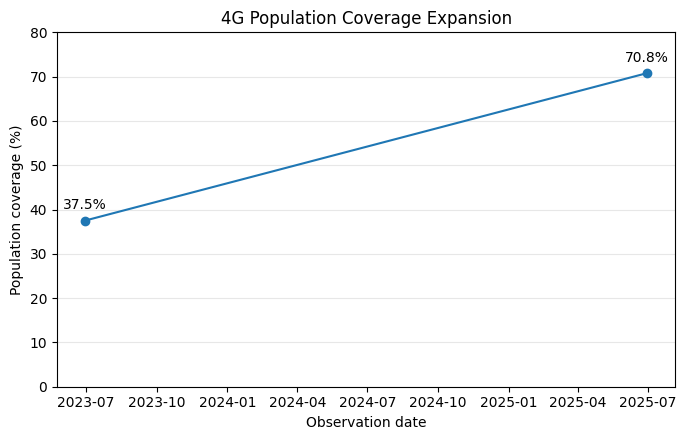

,indicator_code,indicator,observation_date,value_numeric,unit
8,ACC_4G_COV,4G Population Coverage,2023-06-30,37.5,%
9,ACC_4G_COV,4G Population Coverage,2025-06-30,70.8,%
11,ACC_FAYDA,Fayda Digital ID Enrollment,2024-08-15,8000000.0,people
12,ACC_FAYDA,Fayda Digital ID Enrollment,2025-02-28,12000000.0,people
13,ACC_FAYDA,Fayda Digital ID Enrollment,2025-05-15,15000000.0,people
10,ACC_MOBILE_PEN,Mobile Subscription Penetration,2025-12-31,61.4,%


In [19]:
coverage_4g = observation_series(df, "ACC_4G_COV")
display(coverage_4g[["observation_date", "value_numeric", "source_name"]])

plt.figure(figsize=(7, 4.5))
plt.plot(coverage_4g["observation_date"], coverage_4g["value_numeric"], marker="o")
for _, row in coverage_4g.iterrows():
    plt.annotate(f"{row['value_numeric']:.1f}%", (row["observation_date"], row["value_numeric"]), xytext=(0, 8), textcoords="offset points", ha="center")
plt.title("4G Population Coverage Expansion")
plt.xlabel("Observation date")
plt.ylabel("Population coverage (%)")
plt.ylim(0, 80)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_4g_coverage.png", dpi=160, bbox_inches="tight")
plt.show()

infra_snapshot = df.loc[
    df["record_type"].eq("observation")
    & df["indicator_code"].isin(["ACC_4G_COV", "ACC_MOBILE_PEN", "ACC_FAYDA"]),
    ["indicator_code", "indicator", "observation_date", "value_numeric", "unit"],
].sort_values(["indicator_code", "observation_date"])
display(infra_snapshot)

4G population coverage increased from **37.5% to 70.8%**, and mobile subscription penetration reached **61.4%**. These are plausible leading indicators for digital inclusion, but the sparse and non-aligned time series do not support a reliable causal coefficient yet. The access slowdown therefore suggests that infrastructure is necessary but not sufficient; affordability, identity, activity, merchant acceptance, trust, and inclusion gaps also matter.

## 7. Event Timeline and Indicator Overlays

,record_id,observation_date,category,indicator,confidence
33,EVT_0001,2021-05-17,product_launch,Telebirr Launch,high
41,EVT_0009,2021-09-01,policy,NFIS-II Strategy Launch,high
34,EVT_0002,2022-08-01,market_entry,Safaricom Ethiopia Commercial Launch,high
35,EVT_0003,2023-08-01,product_launch,M-Pesa Ethiopia Launch,high
36,EVT_0004,2024-01-01,infrastructure,Fayda Digital ID Program Rollout,high
37,EVT_0005,2024-07-29,policy,Foreign Exchange Liberalization,high
38,EVT_0006,2024-10-01,milestone,P2P Transaction Count Surpasses ATM,high
62,EVT_0011,2025-03-28,policy,National Digital Payments Strategy Phase Two L...,high
39,EVT_0007,2025-10-27,partnership,M-Pesa EthSwitch Integration,high
42,EVT_0010,2025-12-15,pricing,Safaricom Ethiopia Price Increase,high


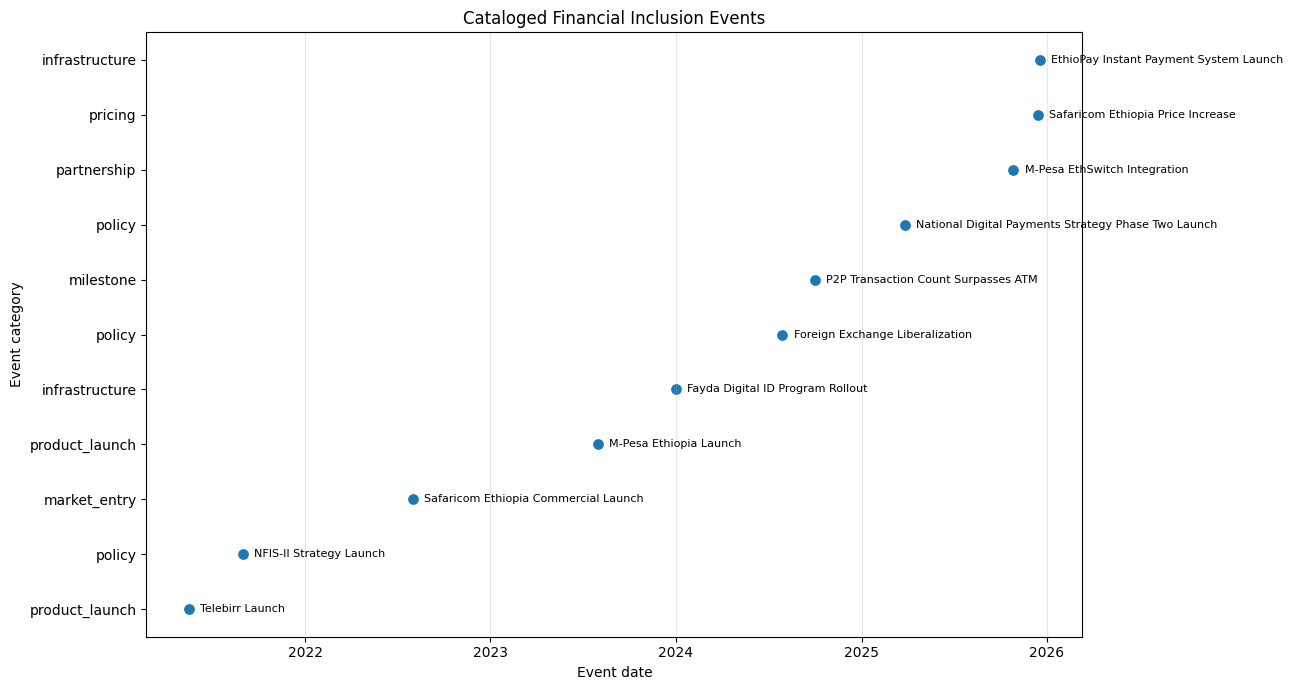

In [20]:
events = records["event"].sort_values("observation_date").copy()
events_display = events[["record_id", "observation_date", "category", "indicator", "confidence"]]
display(events_display)

plt.figure(figsize=(13, 7))
y = np.arange(len(events))
plt.scatter(events["observation_date"], y, s=45)
for pos, (_, row) in enumerate(events.iterrows()):
    plt.annotate(row["indicator"], (row["observation_date"], pos), xytext=(8, 0), textcoords="offset points", va="center", fontsize=8)
plt.yticks(y, events["category"])
plt.title("Cataloged Financial Inclusion Events")
plt.xlabel("Event date")
plt.ylabel("Event category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "15_event_timeline.png", dpi=160, bbox_inches="tight")
plt.show()

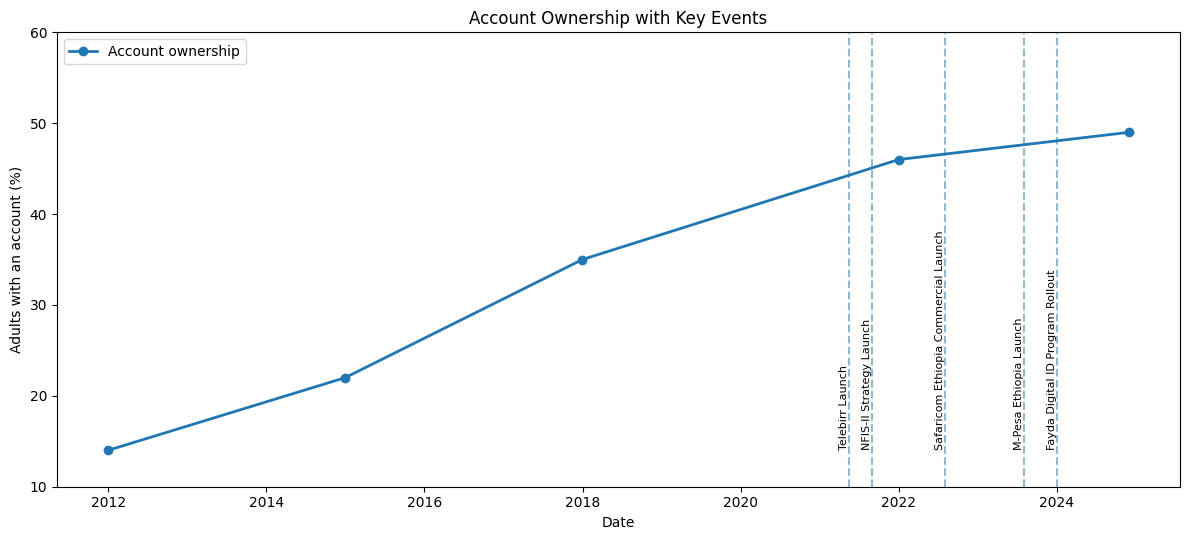

In [21]:
key_access_events = events.loc[events["record_id"].isin(["EVT_0001", "EVT_0002", "EVT_0003", "EVT_0004", "EVT_0009"])]
plt.figure(figsize=(12, 5.5))
plt.plot(account["observation_date"], account["value_numeric"], marker="o", linewidth=2, label="Account ownership")
for _, row in key_access_events.iterrows():
    plt.axvline(row["observation_date"], linestyle="--", alpha=0.5)
    plt.text(row["observation_date"], 14, row["indicator"], rotation=90, va="bottom", ha="right", fontsize=8)
plt.title("Account Ownership with Key Events")
plt.xlabel("Date")
plt.ylabel("Adults with an account (%)")
plt.ylim(10, 60)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "16_access_event_overlay.png", dpi=160, bbox_inches="tight")
plt.show()

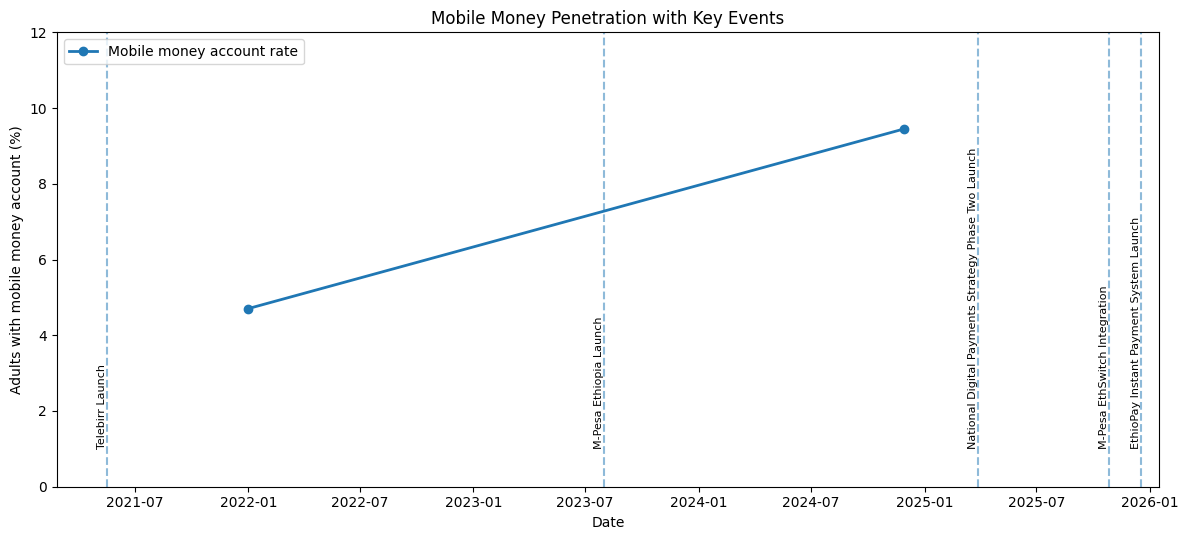

In [22]:
key_usage_events = events.loc[events["record_id"].isin(["EVT_0001", "EVT_0003", "EVT_0007", "EVT_0008", "EVT_0011"])]
plt.figure(figsize=(12, 5.5))
plt.plot(mm_pen["observation_date"], mm_pen["value_numeric"], marker="o", linewidth=2, label="Mobile money account rate")
for _, row in key_usage_events.iterrows():
    plt.axvline(row["observation_date"], linestyle="--", alpha=0.5)
    plt.text(row["observation_date"], 1, row["indicator"], rotation=90, va="bottom", ha="right", fontsize=8)
plt.title("Mobile Money Penetration with Key Events")
plt.xlabel("Date")
plt.ylabel("Adults with mobile money account (%)")
plt.ylim(0, 12)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "17_usage_event_overlay.png", dpi=160, bbox_inches="tight")
plt.show()

The event overlays are descriptive, not causal. Telebirr launched in 2021 and M-Pesa entered in 2023, while mobile-money account penetration rose by 4.75 pp by 2024. However, only two mobile-money survey points exist, and the 2021 baseline coincides with Telebirr's launch, so a clean pre/post estimate is impossible.

## 8. Impact Links and Exploratory Association Analysis

In [23]:
joined_links = joined_impact_links(df)
joined_links.to_csv(ROOT / "data/processed/impact_links_joined.csv", index=False)
display(joined_links[[
    "record_id", "event_name", "pillar", "related_indicator", "relationship_type",
    "impact_direction", "impact_magnitude", "impact_estimate", "lag_months", "confidence"
]].sort_values(["event_name", "pillar"]))

,record_id,event_name,pillar,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,confidence
12,IMP_0013,EthioPay Instant Payment System Launch,USAGE,USG_P2P_COUNT,indirect,increase,medium,15.0,6.0,medium
7,IMP_0008,Fayda Digital ID Program Rollout,ACCESS,ACC_OWNERSHIP,enabling,increase,medium,10.0,24.0,medium
8,IMP_0009,Fayda Digital ID Program Rollout,GENDER,GEN_GAP_ACC,indirect,decrease,medium,-5.0,24.0,medium
9,IMP_0010,Foreign Exchange Liberalization,AFFORDABILITY,AFF_DATA_INCOME,indirect,increase,high,30.0,3.0,high
10,IMP_0011,M-Pesa EthSwitch Integration,USAGE,USG_MPESA_ACTIVE,direct,increase,medium,15.0,3.0,medium
11,IMP_0012,M-Pesa EthSwitch Integration,USAGE,USG_P2P_COUNT,direct,increase,medium,10.0,3.0,medium
6,IMP_0007,M-Pesa Ethiopia Launch,ACCESS,ACC_MM_ACCOUNT,direct,increase,medium,5.0,6.0,medium
5,IMP_0006,M-Pesa Ethiopia Launch,USAGE,USG_MPESA_USERS,direct,increase,high,NaN,3.0,high
15,IMP_0016,National Digital Payments Strategy Phase Two L...,ACCESS,ACC_OWNERSHIP,enabling,increase,medium,5.0,18.0,medium
14,IMP_0015,National Digital Payments Strategy Phase Two L...,USAGE,USG_DIGITAL_PAYMENT,enabling,increase,medium,10.0,12.0,medium


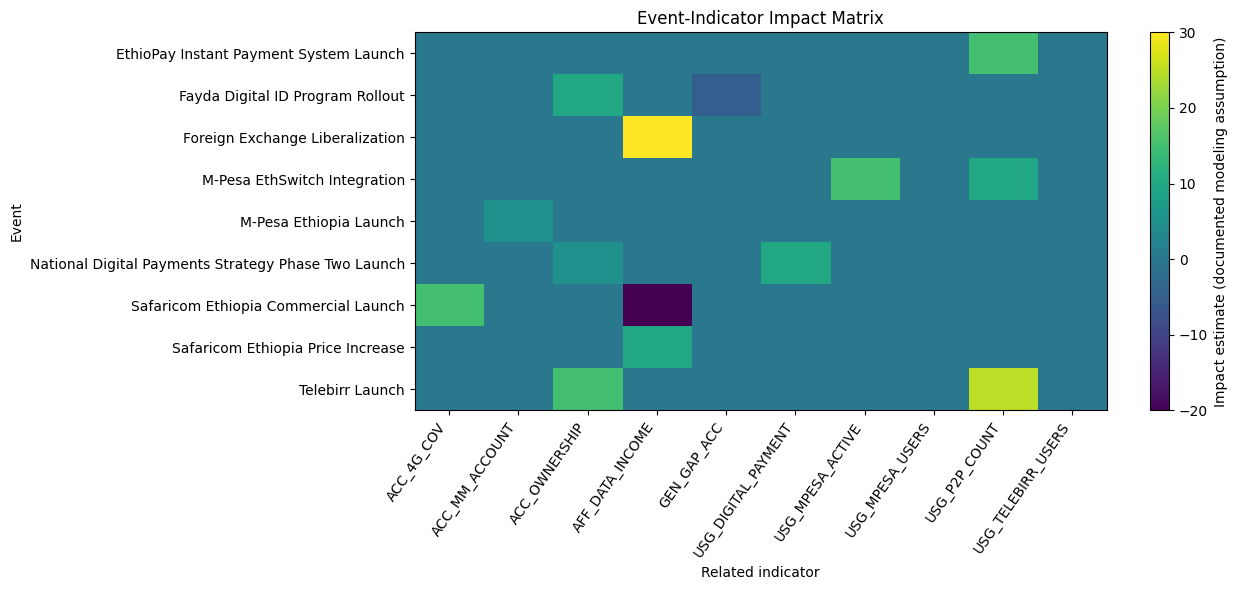

In [24]:
matrix = impact_matrix(df)
plt.figure(figsize=(13, max(6, 0.5 * len(matrix))))
plt.imshow(matrix.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="Impact estimate (documented modeling assumption)")
plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=55, ha="right")
plt.yticks(range(len(matrix.index)), matrix.index)
plt.title("Event-Indicator Impact Matrix")
plt.xlabel("Related indicator")
plt.ylabel("Event")
plt.tight_layout()
plt.savefig(FIG_DIR / "18_impact_link_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

In [25]:
correlations = pairwise_indicator_correlations(df)
display(correlations.head(20).round(3))
print("Pairs with at least 3 overlapping years:", int((correlations["overlap_years"] >= 3).sum()) if not correlations.empty else 0)

,indicator_a,indicator_b,overlap_years,pearson_r
0,ACC_FAYDA,USG_P2P_COUNT,2,1.0
1,ACC_MM_ACCOUNT,ACC_OWNERSHIP,2,1.0
2,ACC_MM_ACCOUNT,GEN_GAP_ACC,2,-1.0
3,ACC_OWNERSHIP,GEN_GAP_ACC,2,-1.0


Pairs with at least 3 overlapping years: 0


The formal correlation exercise confirms a major limitation: nearly all series are irregular and single-point, and almost no indicator pairs share three or more years. Apparent correlations with only two overlapping observations are mathematically unstable and should not be interpreted as evidence. The documented `impact_link` matrix is more transparent for the interim stage because it exposes direction, assumed magnitude, lag, and evidence basis for later sensitivity testing.

## 9. Key Insights

1. **Access growth slowed sharply after 2021.** Account ownership rose from 14% in 2011 to 49% in 2024, but the latest interval added only 3 pp compared with gains of 8-13 pp in earlier intervals. See Figures 6 and 7.

2. **Mobile-money expansion did not translate one-for-one into new unique account owners.** Mobile-money penetration doubled from 4.7% to 9.45%, while total account ownership rose only from 46% to 49%. Registrations can represent duplicate, overlapping, or inactive accounts. See Figures 6, 9, and 13.

3. **Digital transaction usage is accelerating faster than access.** P2P transactions increased 158% year over year to 128.3 million and surpassed ATM transaction count for the first time. The ecosystem is shifting toward digital rails even though survey-measured ownership moved slowly. See Figures 11 and 12.

4. **Activity is the critical missing bridge between registration and inclusion.** M-Pesa had 10.8 million registered users but 7.1 million 90-day active users, an activity rate of about 65.7%. The NBE system-wide active-account estimate is much lower and uses a different definition, emphasizing the need for harmonized activity measures. See Figure 13.

5. **Infrastructure improved substantially but is not sufficient by itself.** 4G coverage almost doubled from 37.5% to 70.8%, yet account ownership growth slowed. Future models should combine connectivity with affordability, digital ID, agent/merchant access, trust, literacy, and activity indicators. See Figure 14.

6. **Gender inclusion remains a binding constraint.** In 2021, male account ownership was 56% versus 36% for women, a 20 pp gap. The dataset estimates an 18 pp gap in 2024, and women held only 14% of mobile-money accounts. See Figure 8.

7. **The dataset is rich in concepts but sparse in time.** Most indicator codes have only one observed year, preventing robust statistical correlations or causal event estimation. Event-impact links must therefore remain explicit hypotheses with sensitivity ranges. See Figure 5 and the impact matrix.

## 10. Preliminary Event-Indicator Hypotheses

- **Telebirr launch -> mobile-money access and P2P usage:** plausible positive relationship, but the Findex baseline and launch occur in the same year.
- **Safaricom market entry -> coverage and affordability:** competition may expand network coverage and reduce costs, though later price increases can offset affordability gains.
- **M-Pesa launch and interoperability -> active users and P2P volume:** provider growth and cross-network functionality support usage, but unique-adult effects require demand-side validation.
- **Fayda digital ID -> account ownership and gender inclusion:** eKYC may lower documentation barriers, with a longer implementation lag.
- **NDPS Phase Two -> digital-payment adoption and access:** the new impact links encode these as medium-confidence enabling hypotheses for Task 3, not as measured causal effects.

## 11. Data Limitations

1. **Sparse irregular time series:** account ownership has five survey observations; most indicators have one point.
2. **Demand-side and supply-side measures differ:** Findex measures people, while operators and regulators often count accounts, subscriptions, or transactions.
3. **Duplicate and inactive accounts:** registered account totals can exceed the adult population and cannot be interpreted as unique inclusion.
4. **Definition mismatch:** provider-specific 90-day activity and system-wide active-account rates are not directly comparable.
5. **Limited disaggregation:** urban/rural, income, education, disability, and regional series are largely missing.
6. **Approximate observations:** 2024 digital-payment and wage-use figures are approximate and marked medium confidence.
7. **Event dates and outcome dates are coarse:** annual or fiscal-year measurements make short-lag impact detection difficult.
8. **No causal identification:** event overlays show timing only; they do not control for macroeconomic shocks, conflict, inflation, policy interactions, or pre-existing trends.
9. **Correlation is underpowered:** pairs with two overlapping points can produce extreme correlations that have no inferential value.
10. **Impact estimates are assumptions:** values in `impact_link` rows require validation, comparable-country evidence, and sensitivity testing in Task 3.

## 12. Interim Conclusion

Ethiopia's financial inclusion story is a divergence between **rapid digital ecosystem expansion** and **slower growth in unique-adult account ownership**. Usage indicators such as P2P volume, mobile-money registrations, and network coverage are growing quickly, but activity, overlap, gender gaps, merchant acceptance, affordability, identity, and trust determine whether that expansion becomes meaningful inclusion.

The next modeling phase should use simple bounded trends, transparent event lags, multiple scenarios, and wide uncertainty intervals rather than parameter-heavy time-series methods.